
# Notebook 07 — Nature-style multipanel figure for the AMP demonstrative case study

This notebook builds a single publication-ready multipanel figure from the outputs generated by Notebooks 02–06.

**Scope:** this figure intentionally excludes the full methodological workflow. It focuses only on the analytical outputs that demonstrate the proposed framework in practice:

- dataset physicochemical signatures,
- explainable prediction,
- uncertainty-aware screening,
- interpretable rule extraction,
- rule-aware prioritization,
- external screening and pseudo-feedback cycle.

The notebook expects the following folders generated by the previous notebooks:

```text
../outputs/
../outputs_training/
../outputs_explainability/
../outputs_rule_prioritization/
../outputs_dtl_cycle/
```

If the notebook is executed from the project root instead of a `notebooks/` directory, it will automatically use `./outputs`, `./outputs_training`, etc.


In [115]:

# ============================================================
# 1. Imports and global configuration
# ============================================================

from __future__ import annotations

import json
import textwrap
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# Publication-style defaults
# -----------------------------

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 14,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
})

RANDOM_STATE = 42
FIG_DPI = 600

# Nature-inspired restrained palette
COLORS = {
    "non_amp": "#5B6670",
    "amp": "#D84A4A",
    "blue": "#4C72B0",
    "teal": "#55A3A3",
    "green": "#3FA164",
    "gold": "#E59E22",
    "purple": "#7A4CC2",
    "gray": "#737373",
    "light_gray": "#EEF1F3",
    "dark": "#111111",
    "line": "#333333",
    "blue_soft": "#EAF1FA",
    "gold_soft": "#FBF3E1",
    "green_soft": "#EAF6EF",
}

# Heatmap palette: blue-white-red, softer and closer to the reference figure.
heatmap_cmap = LinearSegmentedColormap.from_list(
    "soft_blue_white_red",
    ["#1F4E79", "#8DB6D9", "#F7F7F7", "#F4A582", "#B2182B"],
    N=256,
)

uncertainty_cmap = LinearSegmentedColormap.from_list(
    "uncertainty",
    ["#EFF4F7", "#BFDCEC", "#65A9CF", "#1F77B4", "#08306B"],
    N=256,
)

# -----------------------------
# Project path resolution
# -----------------------------

CANDIDATE_ROOTS = [Path(".."), Path(".")]

def find_project_root() -> Path:
    for root in CANDIDATE_ROOTS:
        if (root / "outputs").exists() or (root / "outputs_training").exists():
            return root.resolve()
    # Default to parent, matching notebooks 02-06
    return Path("..").resolve()

PROJECT_ROOT = find_project_root()

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TRAINING_DIR = PROJECT_ROOT / "outputs_training"
EXPLAINABILITY_DIR = PROJECT_ROOT / "outputs_explainability"
RULE_PRIORITY_DIR = PROJECT_ROOT / "outputs_rule_prioritization"
DTL_DIR = PROJECT_ROOT / "outputs_dtl_cycle"

FIGURE_OUT_DIR = PROJECT_ROOT / "paper_figures"
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure output directory:", FIGURE_OUT_DIR)


Project root: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery
Figure output directory: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery/paper_figures



## 2. Load exported artefacts

The file names below are taken directly from Notebooks 02–06:

- Notebook 02: `amp_dataset_with_descriptors.csv`, `statistical_comparison_descriptors.csv`, `descriptor_metadata.csv`
- Notebook 03: `training_metadata.json`, `best_model_selection.json`, selected model predictions
- Notebook 04: `shap_global_importance_directionality.csv`, `manuscript_ready_explainability_summary.csv`
- Notebook 05: `amp_rulebook_from_shap_and_surrogate.csv`, `all_candidates_rule_aware_ranked.csv`, `candidate_pool_summary.csv`
- Notebook 06: `external_candidates_rule_aware_ranked_pre_feedback.csv`, `external_candidates_ranked_after_pseudo_feedback_update.csv`, `manuscript_ready_dtl_cycle_summary.csv`


In [116]:

# ============================================================
# 2. Loading utilities and artefact paths
# ============================================================

def require_file(path: Path, label: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path


def read_csv_required(path: Path, label: str) -> pd.DataFrame:
    path = require_file(path, label)
    return pd.read_csv(path)


def read_json_required(path: Path, label: str) -> dict:
    path = require_file(path, label)
    with open(path, "r") as handle:
        return json.load(handle)


def first_existing(paths: Iterable[Path], label: str) -> Path:
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {label}. Tried:\n" + "\n".join(str(p) for p in paths))

# Notebook 02 outputs
DESCRIPTOR_DATASET_PATH = OUTPUTS_DIR / "amp_dataset_with_descriptors.csv"
STATS_PATH = OUTPUTS_DIR / "statistical_comparison_descriptors.csv"
DESCRIPTOR_METADATA_PATH = OUTPUTS_DIR / "descriptor_metadata.csv"

# Notebook 03 outputs
TRAINING_METADATA_PATH = TRAINING_DIR / "training_metadata.json"
BEST_MODEL_SELECTION_PATH = TRAINING_DIR / "best_model_selection.json"
TRAINING_METRICS_PATH = TRAINING_DIR / "training_metrics.csv"
SPLIT_DATASET_PATH = TRAINING_DIR / "splits" / "amp_model_ready_with_distance_aware_split.csv"

# Notebook 04 outputs
SHAP_IMPORTANCE_PATH = EXPLAINABILITY_DIR / "tables" / "shap_global_importance_directionality.csv"
EXPLAINABILITY_SUMMARY_PATH = EXPLAINABILITY_DIR / "tables" / "manuscript_ready_explainability_summary.csv"

# Notebook 05 outputs
RULEBOOK_PATH = RULE_PRIORITY_DIR / "rules" / "amp_rulebook_from_shap_and_surrogate.csv"
INTERNAL_RANKED_PATH = RULE_PRIORITY_DIR / "tables" / "all_candidates_rule_aware_ranked.csv"
POOL_SUMMARY_PATH = RULE_PRIORITY_DIR / "tables" / "candidate_pool_summary.csv"

# Notebook 06 outputs
EXTERNAL_PRE_FEEDBACK_PATH = DTL_DIR / "tables" / "external_candidates_rule_aware_ranked_pre_feedback.csv"
EXTERNAL_POST_FEEDBACK_PATH = DTL_DIR / "tables" / "external_candidates_ranked_after_pseudo_feedback_update.csv"
DTL_SUMMARY_PATH = DTL_DIR / "tables" / "manuscript_ready_dtl_cycle_summary.csv"
CLEANING_SUMMARY_PATH = DTL_DIR / "tables" / "external_candidate_cleaning_summary.csv"

# Load metadata first, because it points to the selected prediction file
training_metadata = read_json_required(TRAINING_METADATA_PATH, "training metadata")
best_model_info = read_json_required(BEST_MODEL_SELECTION_PATH, "best model selection")

SEQUENCE_COL = training_metadata.get("sequence_column", "sequence")
LABEL_COL = training_metadata.get("label_column", "label")
DESCRIPTOR_COLS = training_metadata["descriptor_columns"]
BEST_MODEL_NAME = best_model_info["best_model"]
SELECTED_PREDICTION_PATH = PROJECT_ROOT / Path(best_model_info["artifacts"]["prediction_path"])
if not SELECTED_PREDICTION_PATH.exists():
    # path may already be relative to current working directory
    SELECTED_PREDICTION_PATH = Path(best_model_info["artifacts"]["prediction_path"])

# Load tables
desc_df = read_csv_required(DESCRIPTOR_DATASET_PATH, "descriptor dataset")
stats_df = read_csv_required(STATS_PATH, "descriptor statistics")
descriptor_metadata_df = read_csv_required(DESCRIPTOR_METADATA_PATH, "descriptor metadata")
training_metrics_df = read_csv_required(TRAINING_METRICS_PATH, "training metrics")
prediction_df = read_csv_required(SELECTED_PREDICTION_PATH, "selected model predictions")
shap_df = read_csv_required(SHAP_IMPORTANCE_PATH, "SHAP global importance")
explainability_summary_df = read_csv_required(EXPLAINABILITY_SUMMARY_PATH, "explainability summary")
rulebook_df = read_csv_required(RULEBOOK_PATH, "rulebook")
internal_ranked_df = read_csv_required(INTERNAL_RANKED_PATH, "internal ranked candidates")
pool_summary_df = read_csv_required(POOL_SUMMARY_PATH, "candidate pool summary")
external_pre_df = read_csv_required(EXTERNAL_PRE_FEEDBACK_PATH, "external pre-feedback ranking")
external_post_df = read_csv_required(EXTERNAL_POST_FEEDBACK_PATH, "external post-feedback ranking")
dtl_summary_df = read_csv_required(DTL_SUMMARY_PATH, "DTL summary")
cleaning_summary_df = read_csv_required(CLEANING_SUMMARY_PATH, "external candidate cleaning summary")

print("Best model:", BEST_MODEL_NAME)
print("Selected prediction file:", SELECTED_PREDICTION_PATH)
print("Descriptor dataset:", desc_df.shape)
print("Prediction table:", prediction_df.shape)
print("SHAP table:", shap_df.shape)
print("Rulebook:", rulebook_df.shape)
print("Internal ranking:", internal_ranked_df.shape)
print("External pre-feedback ranking:", external_pre_df.shape)
print("External post-feedback ranking:", external_post_df.shape)


Best model: extra_trees
Selected prediction file: ../outputs_training/predictions/extra_trees_predictions_with_uncertainty.csv
Descriptor dataset: (47175, 44)
Prediction table: (47175, 8)
SHAP table: (41, 10)
Rulebook: (12, 10)
Internal ranking: (47175, 80)
External pre-feedback ranking: (3890, 85)
External post-feedback ranking: (3890, 95)



## 3. Preprocess figure-ready data

This section harmonizes labels, descriptor names, and selected variables for a compact figure. The goal is not to show all descriptors, but to select interpretable variables that communicate the biological and computational signal clearly.


In [117]:

# ============================================================
# 3. Preprocess figure-ready data
# ============================================================

# Human-readable labels for selected descriptors
FEATURE_LABELS = {
    "length": "Length",
    "molecular_weight": "Molecular\nweight",
    "shannon_entropy": "Shannon\nentropy",
    "normalized_entropy": "Normalized\nentropy",
    "unique_residue_fraction": "Unique residue\nfraction",
    "net_charge_pH_7_4": "Net charge\n(pH 7.4)",
    "absolute_charge_pH_7_4": "Absolute\ncharge",
    "isoelectric_point_approx": "Approx. pI",
    "positive_fraction": "Positive\nfraction",
    "negative_fraction": "Negative\nfraction",
    "charged_fraction": "Charged\nfraction",
    "hydrophobic_fraction": "Hydrophobic\nfraction",
    "polar_fraction": "Polar\nfraction",
    "aromatic_fraction": "Aromatic\nfraction",
    "small_fraction": "Small residue\nfraction",
    "gravy": "GRAVY",
    "aliphatic_index": "Aliphatic\nindex",
    "instability_proxy": "Instability\nproxy",
    "helix_propensity": "Helix\npropensity",
    "sheet_propensity": "Sheet\npropensity",
    "turn_propensity": "Turn\npropensity",
}

# Core descriptors for Panel A
panel_a_features = [
    "net_charge_pH_7_4",
    "positive_fraction",
    "hydrophobic_fraction",
    "gravy",
    "shannon_entropy",
    "length",
    "helix_propensity",
    "instability_proxy",
]
panel_a_features = [f for f in panel_a_features if f in desc_df.columns]

# Z-score class means for heatmap-like compact comparison
class_mean = desc_df.groupby("label_name")[panel_a_features].mean()
feature_mean = desc_df[panel_a_features].mean()
feature_std = desc_df[panel_a_features].std().replace(0, np.nan)
class_mean_z = ((class_mean - feature_mean) / feature_std).T

# Enforce row order and class order
class_order = [c for c in ["non-AMP", "AMP"] if c in class_mean_z.columns]
if len(class_order) == 2:
    class_mean_z = class_mean_z[class_order]

class_mean_z.index = [FEATURE_LABELS.get(idx, idx) for idx in class_mean_z.index]

# SHAP top features
shap_plot_df = shap_df.sort_values("mean_abs_shap", ascending=False).head(10).copy()
shap_plot_df["feature_label"] = shap_plot_df["feature"].map(lambda x: FEATURE_LABELS.get(x, x.replace("_", " ")))

# Prediction table: sample for plotting if large
prediction_plot_df = prediction_df.copy()
if LABEL_COL in prediction_plot_df.columns:
    prediction_plot_df["label_name"] = prediction_plot_df[LABEL_COL].map({0: "non-AMP", 1: "AMP"})
else:
    prediction_plot_df["label_name"] = "candidate"

if len(prediction_plot_df) > 7000:
    prediction_plot_df = prediction_plot_df.sample(7000, random_state=RANDOM_STATE)

# Rulebook top rules
rules_plot_df = rulebook_df.sort_values("rule_weight", ascending=False).head(6).copy()
if "rule_text" not in rules_plot_df.columns:
    # Defensive fallback
    def build_rule_text(row):
        feature = row.get("feature", "feature")
        op = row.get("operator", "")
        low = row.get("lower_bound", np.nan)
        up = row.get("upper_bound", np.nan)
        if op == ">=":
            return f"{feature} ≥ {low:.3g}"
        if op == "<=":
            return f"{feature} ≤ {up:.3g}"
        return f"{low:.3g} ≤ {feature} ≤ {up:.3g}"
    rules_plot_df["rule_text"] = rules_plot_df.apply(build_rule_text, axis=1)

rules_plot_df["feature_label"] = rules_plot_df["feature"].map(lambda x: FEATURE_LABELS.get(x, x.replace("_", " ")))

# Internal prioritization table
ranked_plot_df = internal_ranked_df.copy()
if len(ranked_plot_df) > 8000:
    ranked_plot_df = ranked_plot_df.sample(8000, random_state=RANDOM_STATE)

# External candidate summaries
external_plot_df = external_pre_df.copy()
if len(external_plot_df) > 8000:
    external_plot_df = external_plot_df.sample(8000, random_state=RANDOM_STATE)

# DTL summary table already contains components and n_items
print("Panel A features:", panel_a_features)
print("Top SHAP features:", shap_plot_df["feature"].tolist())
print("Top rules:", rules_plot_df["rule_text"].tolist())


Panel A features: ['net_charge_pH_7_4', 'positive_fraction', 'hydrophobic_fraction', 'gravy', 'shannon_entropy', 'length', 'helix_propensity', 'instability_proxy']
Top SHAP features: ['AAC_K', 'AAC_M', 'isoelectric_point_approx', 'positive_fraction', 'small_fraction', 'polar_fraction', 'unique_residue_fraction', 'AAC_S', 'net_charge_pH_7_4', 'charged_fraction']
Top rules: ['AAC_K >= 0.08333', 'positive_fraction >= 0.2857', 'AAC_M <= 0', 'isoelectric_point_approx >= 10.84', 'small_fraction <= 0.3333', 'net_charge_pH_7_4 >= 2.994']



## 4. Plotting helper functions


In [118]:

# ============================================================
# 4. Helper functions for Nature-style panels
# ============================================================

def panel_label(ax, label: str, x: float = -0.13, y: float = 1.10) -> None:
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left",
        color=COLORS["dark"],
    )


def clean_axis(ax, despine: bool = True) -> None:
    ax.grid(False)
    if despine:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", length=3.5, width=0.8, color=COLORS["line"])


def add_subtitle(ax, text: str) -> None:
    ax.set_title(text, loc="left", fontsize=12, fontweight="bold", pad=8)


def truncate_label(text: str, width: int = 38) -> str:
    return "\n".join(textwrap.wrap(str(text), width=width))


def draw_rounded_box(ax, xy, width, height, text, fc="#FFFFFF", ec="#333333", lw=1.0, fontsize=9, weight="normal"):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=lw,
        facecolor=fc,
        edgecolor=ec,
        transform=ax.transAxes,
        clip_on=False,
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=weight,
        color=COLORS["dark"],
        transform=ax.transAxes,
    )
    return box


def draw_arrow(ax, start, end, color="#4A4A4A", lw=1.0, mutation_scale=11):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        shrinkA=2,
        shrinkB=2,
        transform=ax.transAxes,
        clip_on=False,
    )
    ax.add_patch(arrow)
    return arrow


def normalize_to_unit(values: pd.Series) -> pd.Series:
    values = pd.to_numeric(values, errors="coerce")
    vmin = values.min()
    vmax = values.max()
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
        return pd.Series(np.zeros(len(values)), index=values.index)
    return (values - vmin) / (vmax - vmin)



## 5. Build the multipanel figure

Recommended panel organization:

- **A:** Physicochemical signatures of AMP and non-AMP sequences.
- **B:** SHAP-derived feature importance.
- **C:** Uncertainty-aware predictive map.
- **D:** Interpretable rules extracted from SHAP and surrogate evidence.
- **E:** Rule-aware prioritization map.
- **F:** External screening and pseudo-feedback cycle summary.


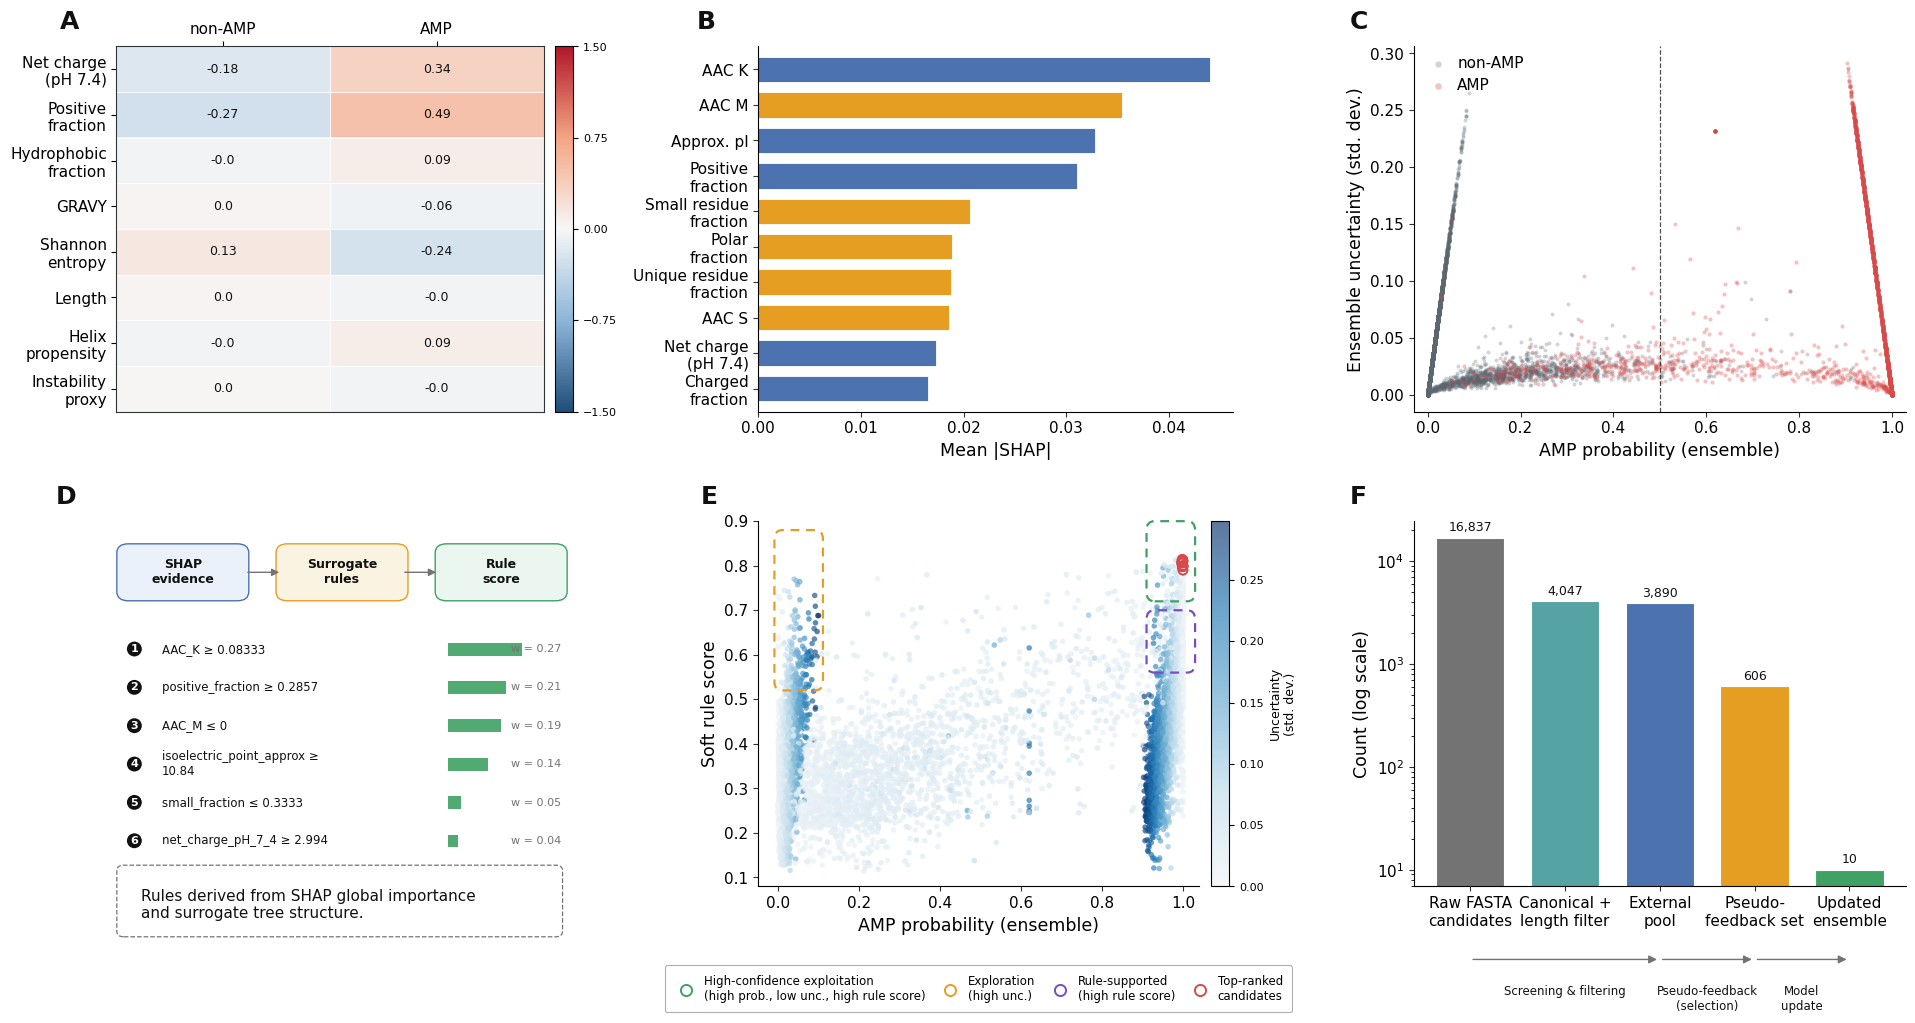

Saved: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery/paper_figures/figure_amp_demonstrative_case_multipanel.png
Saved: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery/paper_figures/figure_amp_demonstrative_case_multipanel.pdf
Saved: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery/paper_figures/figure_amp_demonstrative_case_multipanel.svg


In [119]:

# ============================================================
# 5. Build Nature-style multipanel figure
# ============================================================

fig = plt.figure(figsize=(20, 10.5), constrained_layout=False)
outer = gridspec.GridSpec(
    nrows=2,
    ncols=3,
    figure=fig,
    height_ratios=[1.0, 1.0],
    width_ratios=[1.05, 1.08, 1.12],
    hspace=0.30,
    wspace=0.38,
)

# ------------------------------------------------------------
# Panel A — Dataset physicochemical signatures
# ------------------------------------------------------------
axA = fig.add_subplot(outer[0, 0])

im = axA.imshow(
    class_mean_z.values,
    aspect="auto",
    cmap=heatmap_cmap,
    vmin=-1.5,
    vmax=1.5,
    interpolation="nearest",
)

# subtle cell borders
for x in np.arange(-0.5, class_mean_z.shape[1], 1):
    axA.axvline(x, color="white", lw=0.8, alpha=0.85)
for y in np.arange(-0.5, class_mean_z.shape[0], 1):
    axA.axhline(y, color="white", lw=0.8, alpha=0.85)

axA.set_xticks(np.arange(class_mean_z.shape[1]))
axA.set_xticklabels(class_mean_z.columns, rotation=0)
axA.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, pad=3)
axA.set_yticks(np.arange(class_mean_z.shape[0]))
axA.set_yticklabels(class_mean_z.index)
axA.set_xlabel("")
axA.set_ylabel("")
panel_label(axA, "A")

# Cell labels
for i in range(class_mean_z.shape[0]):
    for j in range(class_mean_z.shape[1]):
        val = class_mean_z.values[i, j]
        axA.text(
            j,
            i,
            f"{val:.2f}" if abs(val) >= 0.05 else f"{val:.1f}",
            ha="center",
            va="center",
            fontsize=9,
            color="#111111",
        )

cbarA = fig.colorbar(im, ax=axA, fraction=0.048, pad=0.025)
cbarA.set_ticks([-1.5, -0.75, 0, 0.75, 1.5])
cbarA.ax.tick_params(labelsize=8)

for spine in axA.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("#2F3437")

# ------------------------------------------------------------
# Panel B — SHAP feature importance
# ------------------------------------------------------------
axB = fig.add_subplot(outer[0, 1])

plot_b = shap_plot_df.iloc[::-1].copy()
y_pos = np.arange(len(plot_b))
directions = plot_b.get("interpretable_direction", pd.Series([""] * len(plot_b)))
bar_colors = [
    COLORS["blue"] if d != "lower_values_support_AMP_prediction" else COLORS["gold"]
    for d in directions
]

axB.barh(
    y_pos,
    plot_b["mean_abs_shap"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.6,
    height=0.72,
)
axB.set_yticks(y_pos)
axB.set_yticklabels(plot_b["feature_label"])
axB.set_xlabel("Mean |SHAP|")
panel_label(axB, "B")
clean_axis(axB)
axB.set_xlim(left=0)
axB.margins(y=0.03)

# ------------------------------------------------------------
# Panel C — Uncertainty-aware prediction map
# ------------------------------------------------------------
axC = fig.add_subplot(outer[0, 2])

# Draw non-AMP first, then AMP to keep AMP points visible.
label_order = ["non-AMP", "AMP"]
for label_name in label_order:
    if label_name not in set(prediction_plot_df["label_name"]):
        continue
    group = prediction_plot_df[prediction_plot_df["label_name"].eq(label_name)]
    axC.scatter(
        group["probability_amp_ensemble"],
        group["uncertainty_std"],
        s=8 if label_name == "non-AMP" else 9,
        alpha=0.28 if label_name == "non-AMP" else 0.32,
        linewidth=0,
        color=COLORS["non_amp"] if label_name == "non-AMP" else COLORS["amp"],
        label=label_name,
        rasterized=True,
    )

axC.axvline(0.5, color=COLORS["line"], linewidth=0.9, linestyle="--", alpha=0.85)
axC.set_xlabel("AMP probability (ensemble)")
axC.set_ylabel("Ensemble uncertainty (std. dev.)")
panel_label(axC, "C")
clean_axis(axC)
axC.legend(
    frameon=False,
    loc="upper left",
    handletextpad=0.25,
    borderpad=0.1,
    markerscale=1.6,
)
axC.set_xlim(-0.03, 1.03)

# ------------------------------------------------------------
# Panel D — Rule extraction summary
# ------------------------------------------------------------
axD = fig.add_subplot(outer[1, 0])
axD.set_axis_off()
panel_label(axD, "D")


# Header boxes
box_y = 0.80
draw_rounded_box(
    axD, (0.02, box_y), 0.25, 0.12,
    "SHAP\nevidence",
    fc=COLORS["blue_soft"],
    ec=COLORS["blue"],
    fontsize=9,
    weight="bold",
)
draw_rounded_box(
    axD, (0.365, box_y), 0.25, 0.12,
    "Surrogate\nrules",
    fc=COLORS["gold_soft"],
    ec=COLORS["gold"],
    fontsize=9,
    weight="bold",
)
draw_rounded_box(
    axD, (0.71, box_y), 0.25, 0.12,
    "Rule\nscore",
    fc=COLORS["green_soft"],
    ec=COLORS["green"],
    fontsize=9,
    weight="bold",
)
draw_arrow(axD, (0.28, box_y + 0.06), (0.36, box_y + 0.06), color=COLORS["gray"], lw=1.0)
draw_arrow(axD, (0.62, box_y + 0.06), (0.70, box_y + 0.06), color=COLORS["gray"], lw=1.0)

# Rule list
start_y = 0.65
line_height = 0.105
max_weight = max(float(rules_plot_df["rule_weight"].max()), 1e-8)

for idx, (_, row) in enumerate(rules_plot_df.iterrows(), start=1):
    y = start_y - (idx - 1) * line_height
    weight = float(row.get("rule_weight", np.nan))
    rule_text = row.get("rule_text", "")
    short_rule = truncate_label(str(rule_text).replace(">=", "≥").replace("<=", "≤"), width=31)

    # Circular numbered bullet
    axD.text(
        0.04,
        y,
        f"{idx}",
        fontsize=8,
        fontweight="bold",
        color="white",
        ha="center",
        va="center",
        bbox=dict(boxstyle="circle,pad=0.22", fc=COLORS["dark"], ec="none"),
        transform=axD.transAxes,
    )

    # Rule text
    axD.text(
        0.10,
        y,
        short_rule,
        fontsize=8.5,
        va="center",
        color=COLORS["dark"],
        transform=axD.transAxes,
    )

    # Weight bar and separated text
    bar_start = 0.72
    bar_max_width = 0.16
    bar_width = bar_max_width * min(weight / max_weight, 1.0)

    axD.add_patch(
        Rectangle(
            (bar_start, y - 0.018),
            bar_width,
            0.035,
            transform=axD.transAxes,
            facecolor=COLORS["green"],
            edgecolor="none",
            alpha=0.90,
        )
    )
    axD.text(
        0.965,
        y,
        f"w = {weight:.2f}",
        fontsize=8,
        va="center",
        ha="right",
        color=COLORS["gray"],
        transform=axD.transAxes,
    )

# Note box at bottom
note_box = FancyBboxPatch(
    (0.02, -0.12),
    0.93,
    0.16,
    boxstyle="round,pad=0.018,rounding_size=0.015",
    linewidth=0.9,
    linestyle="--",
    facecolor="white",
    edgecolor=COLORS["gray"],
    transform=axD.transAxes,
    clip_on=False,
)

axD.add_patch(note_box)
axD.text(
    0.055,
    -0.05,
    "Rules derived from SHAP global importance\nand surrogate tree structure.",
    transform=axD.transAxes,
    fontsize=11,
    va="center",
    ha="left",
    color=COLORS["dark"],
)

# ------------------------------------------------------------
# Panel E — Rule-aware prioritization map
# ------------------------------------------------------------
axE = fig.add_subplot(outer[1, 1])

scatterE = axE.scatter(
    ranked_plot_df["probability_amp_ensemble"],
    ranked_plot_df["soft_rule_score"],
    c=ranked_plot_df["uncertainty_std"],
    s=16,
    alpha=0.65,
    cmap=uncertainty_cmap,
    linewidth=0,
    rasterized=True,
)

# Highlight top candidates if available
if "priority_rank" in internal_ranked_df.columns:
    top_df = internal_ranked_df.sort_values("priority_rank").head(25)
else:
    top_df = internal_ranked_df.sort_values("rule_aware_priority_score", ascending=False).head(25)

axE.scatter(
    top_df["probability_amp_ensemble"],
    top_df["soft_rule_score"],
    s=42,
    facecolor="none",
    edgecolor=COLORS["amp"],
    linewidth=1.2,
    label="Top-ranked\ncandidates",
    zorder=5,
)

# Region boxes in data coordinates for reproducibility and visual clarity
region_specs = [
    {
        "xy": (0.92, 0.73),
        "width": 0.10,
        "height": 0.16,
        "edgecolor": COLORS["green"],
        "label": "High-confidence exploitation\n(high prob., low unc., high rule score)",
    },
    {
        "xy": (0.92, 0.57),
        "width": 0.10,
        "height": 0.12,
        "edgecolor": COLORS["purple"],
        "label": "Rule-supported\n(high rule score)",
    },
    {
        "xy": (0.00, 0.53),
        "width": 0.10,
        "height": 0.34,
        "edgecolor": COLORS["gold"],
        "label": "Exploration\n(high unc.)",
    },
]

for spec in region_specs:
    axE.add_patch(
        FancyBboxPatch(
            spec["xy"],
            spec["width"],
            spec["height"],
            boxstyle="round,pad=0.01,rounding_size=0.02",
            ec=spec["edgecolor"],
            fc="none",
            ls=(0, (4, 3)),
            lw=1.6,
            transform=axE.transData,
            clip_on=False,
        )
    )

axE.set_xlabel("AMP probability (ensemble)")
axE.set_ylabel("Soft rule score")
panel_label(axE, "E")
clean_axis(axE)
axE.set_xlim(-0.05, 1.04)
axE.set_ylim(0.08, max(0.90, float(ranked_plot_df["soft_rule_score"].max()) + 0.04))

cbarE = fig.colorbar(scatterE, ax=axE, fraction=0.046, pad=0.025)
cbarE.set_label("Uncertainty\n(std. dev.)", fontsize=9)
cbarE.ax.tick_params(labelsize=8)

# Custom legend below panel, matching reference styling
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor=COLORS["green"],
           markeredgewidth=1.4, markersize=8, label="High-confidence exploitation\n(high prob., low unc., high rule score)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor=COLORS["gold"],
           markeredgewidth=1.4, markersize=8, label="Exploration\n(high unc.)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor=COLORS["purple"],
           markeredgewidth=1.4, markersize=8, label="Rule-supported\n(high rule score)"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor=COLORS["amp"],
           markeredgewidth=1.4, markersize=8, label="Top-ranked\ncandidates"),
]

leg = axE.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.50, -0.20),
    ncol=4,
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    fontsize=8.5,
    handletextpad=0.5,
    columnspacing=1.1,
    borderpad=0.8,
)
leg.get_frame().set_linewidth(0.8)
leg.get_frame().set_edgecolor("#B0B0B0")

# ------------------------------------------------------------
# Panel F — External screening and DTL summary
# ------------------------------------------------------------
axF = fig.add_subplot(outer[1, 2])
panel_label(axF, "F")

# Build compact funnel data
stage_lookup = {
    "raw_uniprot_candidates": "Raw FASTA\ncandidates",
    "after_sequence_deduplication": "Deduplicated",
    "after_canonical_and_length_filtering": "Canonical +\nlength filter",
    "after_excluding_explicit_antimicrobial_annotations": "AMP annotation\nexcluded",
    "after_optional_signal_or_secreted_filter": "Metadata\nfilter",
    "after_removing_training_sequences": "External\npool",
}

cleaning_for_plot = cleaning_summary_df.copy()
cleaning_for_plot["stage_label"] = cleaning_for_plot["stage"].map(stage_lookup).fillna(cleaning_for_plot["stage"])

# Keep the most informative stages and avoid too many bars
wanted_stages = [
    "raw_uniprot_candidates",
    "after_canonical_and_length_filtering",
    "after_removing_training_sequences",
]
cleaning_for_plot = cleaning_for_plot[cleaning_for_plot["stage"].isin(wanted_stages)].copy()

pseudo_n = int(dtl_summary_df.loc[dtl_summary_df["component"].eq("Pseudo-feedback"), "n_items"].iloc[0]) if "Pseudo-feedback" in set(dtl_summary_df["component"]) else 0
updated_n = int(dtl_summary_df.loc[dtl_summary_df["component"].eq("Illustrative learning update"), "n_items"].iloc[0]) if "Illustrative learning update" in set(dtl_summary_df["component"]) else 0

funnel_df = pd.DataFrame({
    "stage": list(cleaning_for_plot["stage_label"]) + ["Pseudo-\nfeedback set", "Updated\nensemble"],
    "count": list(cleaning_for_plot["n_candidates"].astype(int)) + [pseudo_n, updated_n],
})

bar_colors = [COLORS["gray"], COLORS["teal"], COLORS["blue"], COLORS["gold"], COLORS["green"]][:len(funnel_df)]
bars = axF.bar(
    np.arange(len(funnel_df)),
    funnel_df["count"].replace(0, 0.5),
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.72,
)

for bar, count in zip(bars, funnel_df["count"]):
    axF.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.08,
        f"{int(count):,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=COLORS["dark"],
    )

axF.set_xticks(np.arange(len(funnel_df)))
axF.set_xticklabels(funnel_df["stage"], rotation=0, ha="center")
axF.set_ylabel("Count (log scale)")
axF.set_yscale("log")
clean_axis(axF)

# Bottom process arrows and labels in x-axis transform
xtrans = axF.get_xaxis_transform()
arrow_y = -0.20
label_y = -0.27

arrow_specs = [
    (0, 2, "Screening & filtering"),
    (2, 3, "Pseudo-feedback\n(selection)"),
    (3, 4, "Model\nupdate"),
]

for start, end, label in arrow_specs:
    axF.annotate(
        "",
        xy=(end, arrow_y),
        xytext=(start, arrow_y),
        xycoords=xtrans,
        textcoords=xtrans,
        arrowprops=dict(arrowstyle="-|>", lw=1.0, color=COLORS["gray"]),
        clip_on=False,
    )
    axF.text(
        (start + end) / 2,
        label_y,
        label,
        transform=xtrans,
        ha="center",
        va="top",
        fontsize=8.5,
        color=COLORS["dark"],
        clip_on=False,
    )

# Layout and export
fig.subplots_adjust(
    top=0.96,
    bottom=0.16,
    left=0.08,
    right=0.975,
    wspace=0.38,
    hspace=0.45,
)

png_path = FIGURE_OUT_DIR / "figure_amp_demonstrative_case_multipanel.png"
pdf_path = FIGURE_OUT_DIR / "figure_amp_demonstrative_case_multipanel.pdf"
svg_path = FIGURE_OUT_DIR / "figure_amp_demonstrative_case_multipanel.svg"

fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)
print("Saved:", svg_path)



## 6. Optional standalone panels

This section exports each panel separately. This is useful if the journal layout requires rearranging panels manually in Illustrator, Inkscape, Affinity Designer, or PowerPoint.


In [120]:

# ============================================================
# 6. Optional standalone export helper
# ============================================================

SAVE_STANDALONE_PANELS = False

if SAVE_STANDALONE_PANELS:
    print("Standalone panel export is not duplicated by default to avoid visual drift.")
    print("Set SAVE_STANDALONE_PANELS=True and copy individual plotting blocks if needed.")
else:
    print("Standalone panels skipped. Main multipanel figure already exported.")


Standalone panels skipped. Main multipanel figure already exported.



## 7. Suggested caption draft

```text
Figure X. Illustrative implementation of the proposed explainable and adaptive AMP discovery framework. 
(A) Physicochemical descriptor signatures of AMP and non-AMP sequences in the curated Peptipedia-derived dataset, shown as class-level z-scored descriptor means. 
(B) Global SHAP feature importance for the selected uncertainty-aware baseline model, highlighting the descriptors that most strongly shaped AMP predictions. 
(C) Ensemble-based prediction map showing AMP probability and predictive uncertainty across the curated dataset. 
(D) Translation of explainability evidence into interpretable descriptor rules, combining SHAP-derived feature relevance with surrogate-rule evidence to produce weighted rule criteria. 
(E) Rule-aware prioritization map in which candidates are ranked by combining predicted AMP probability, interpretable rule support, and uncertainty-derived confidence. Highlighted points indicate top-ranked candidates. 
(F) External candidate screening and pseudo-feedback summary, illustrating how an external FASTA-derived candidate pool can be filtered, prioritized, and incorporated into an illustrative design–test–learn update. Pseudo-feedback labels are in silico model-supported labels and do not represent experimental validation.
```
